In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 8

# CatBoost Regression

---

### Objectives

- Load Dataset
- Train CatBoost Regressor
- Evaluate Performance
- Feature Importance
- Save Model

In [ ]:
# ==============================================================================
# INSTALL REQUIRED LIBRARIES
# ==============================================================================

# Uncomment if required

# %pip install catboost
# %pip install joblib

In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==============================================================================
# DISPLAY SETTINGS
# ==============================================================================

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [2]:
# ==============================================================================
# LOAD DATASET
# ==============================================================================

df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\dataset\retail_cleaned.csv")

print("Dataset Shape :",df.shape)

Dataset Shape : (8601, 33)


In [3]:
# ==============================================================================
# DEFINE TARGET
# ==============================================================================

TARGET="Sales"

X=df.drop(columns=[TARGET])

y=df[TARGET]

In [4]:
# ==============================================================================
# REMOVE UNUSED COLUMNS
# ==============================================================================

if "Date" in X.columns:
    X.drop(columns=["Date"], inplace=True)

if "Sales_Per_Customer" in X.columns:
    X.drop(columns=["Sales_Per_Customer"], inplace=True)

print(X.shape)

(8601, 30)


In [5]:
# ==============================================================================
# LABEL ENCODING
# ==============================================================================

encoder=LabelEncoder()

for col in X.select_dtypes(include="object").columns:

    X[col]=encoder.fit_transform(X[col])

print("Encoding Completed")

Encoding Completed


In [6]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(6880, 30)
(1721, 30)


In [7]:
# ==============================================================================
# CREATE CATBOOST MODEL
# ==============================================================================

cat_model=CatBoostRegressor(

    iterations=500,

    learning_rate=0.05,

    depth=8,

    loss_function="RMSE",

    random_seed=42,

    verbose=False

)

print(cat_model)

CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)


In [8]:
# ==============================================================================
# TRAIN MODEL
# ==============================================================================

cat_model.fit(

    X_train,

    y_train

)

print("CatBoost Model Trained Successfully")

CatBoost Model Trained Successfully


In [10]:
# ==============================================================================
# TRAIN PREDICTIONS
# ==============================================================================

y_train_pred=cat_model.predict(X_train)

In [11]:
# ==============================================================================
# TEST PREDICTIONS
# ==============================================================================

y_test_pred=cat_model.predict(X_test)

In [12]:
# ==============================================================================
# MODEL EVALUATION
# ==============================================================================

mae=mean_absolute_error(y_test,y_test_pred)

mse=mean_squared_error(y_test,y_test_pred)

rmse=np.sqrt(mse)

r2=r2_score(y_test,y_test_pred)

print("MAE :",round(mae,2))

print("MSE :",round(mse,2))

print("RMSE :",round(rmse,2))

print("R² :",round(r2,4))

MAE : 8.09
MSE : 103.85
RMSE : 10.19
R² : 0.9635


In [13]:
# ==============================================================================
# PERFORMANCE TABLE
# ==============================================================================

performance=pd.DataFrame({

    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],

    "Value":[
        mae,
        mse,
        rmse,
        r2
    ]

})

performance

,Metric,Value
0,MAE,8.088697
1,MSE,103.846355
2,RMSE,10.190503
3,R²,0.963514


In [14]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

prediction_df=pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_test_pred,

    "Error":y_test-y_test_pred

})

prediction_df.head(20)

,Actual,Predicted,Error
5839,6,9.018219,-3.018219
4275,91,94.764267,-3.764267
6086,49,41.258334,7.741666
8265,90,88.200336,1.799664
5493,15,21.183035,-6.183035
1688,127,110.859657,16.140343
5241,59,48.975690,10.024310
221,53,65.382458,-12.382458
239,63,65.054895,-2.054895
2208,53,59.190430,-6.190430


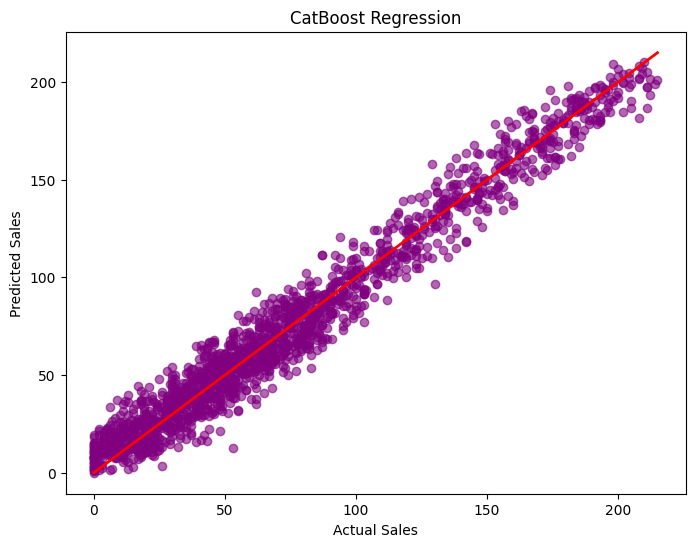

In [15]:
# ==============================================================================
# ACTUAL VS PREDICTED SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_test_pred,

    alpha=0.6,

    color="purple"

)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color="red",

    linewidth=2

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("CatBoost Regression")

plt.show()

In [16]:
# ==============================================================================
# FEATURE IMPORTANCE
# ==============================================================================

importance=pd.DataFrame({

    "Feature":X.columns,

    "Importance":cat_model.get_feature_importance()

})

importance=importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(15)

,Feature,Importance
5,Promotion,54.912694
15,Customers,25.480356
29,Promotion_Impact,10.181680
4,Holiday,2.940077
14,Discount,0.887477
8,Fuel_Price,0.381557
11,Inventory,0.355149
1,Product_ID,0.340571
25,Inventory_Per_Customer,0.322620
10,Unemployment,0.314515


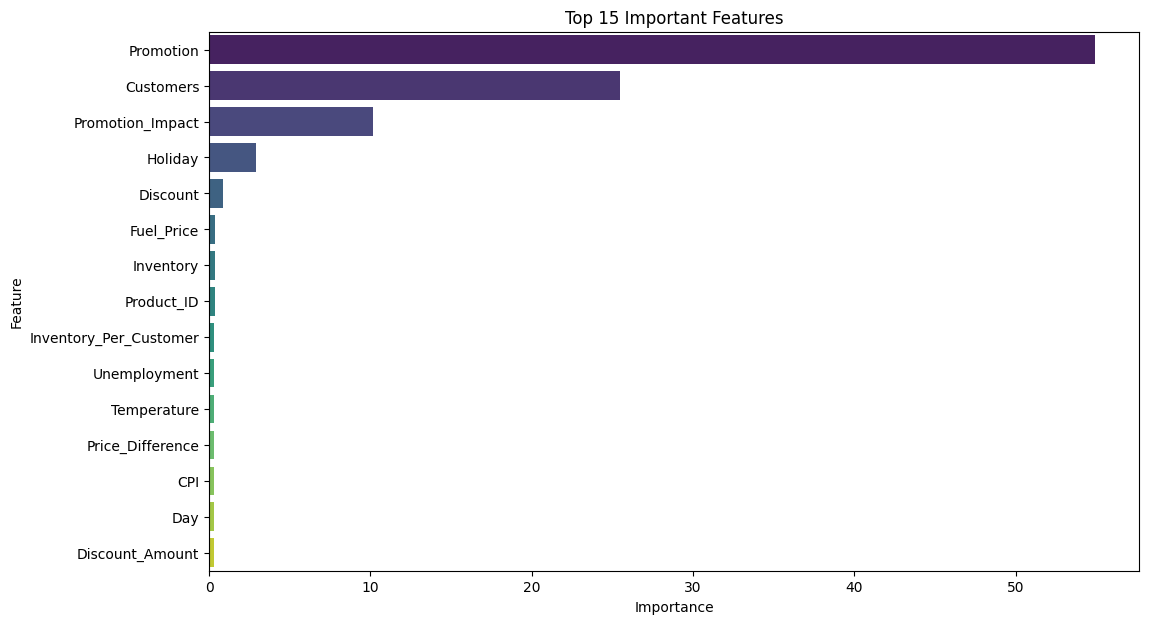

In [17]:
# ==============================================================================
# FEATURE IMPORTANCE PLOT
# ==============================================================================

plt.figure(figsize=(12,7))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Important Features")

plt.show()

In [19]:
# ==============================================================================
# TRAINING R² SCORE
# ==============================================================================

train_r2 = r2_score(y_train, y_train_pred)

print("Training R² Score :", round(train_r2,4))

Training R² Score : 0.9857


In [20]:
# ==============================================================================
# TESTING R² SCORE
# ==============================================================================

test_r2 = r2_score(y_test, y_test_pred)

print("Testing R² Score :", round(test_r2,4))

Testing R² Score : 0.9635


In [21]:
# ==============================================================================
# ADJUSTED R² SCORE
# ==============================================================================

n = X_test.shape[0]

p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print("Adjusted R² :", round(adjusted_r2,4))

Adjusted R² : 0.9629


In [22]:
# ==============================================================================
# MEAN ABSOLUTE PERCENTAGE ERROR (MAPE)
# ==============================================================================

mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("MAPE :", round(mape,2), "%")

MAPE : inf %


In [23]:
# ==============================================================================
# RESIDUALS
# ==============================================================================

residuals = y_test - y_test_pred

prediction_df["Residual"] = residuals

prediction_df.head()

,Actual,Predicted,Error,Residual
5839,6,9.018219,-3.018219,-3.018219
4275,91,94.764267,-3.764267,-3.764267
6086,49,41.258334,7.741666,7.741666
8265,90,88.200336,1.799664,1.799664
5493,15,21.183035,-6.183035,-6.183035


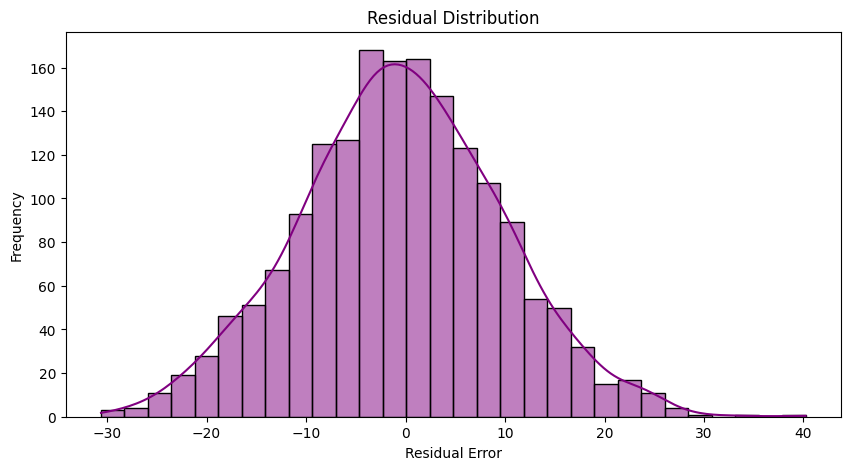

In [24]:
# ==============================================================================
# RESIDUAL DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.show()

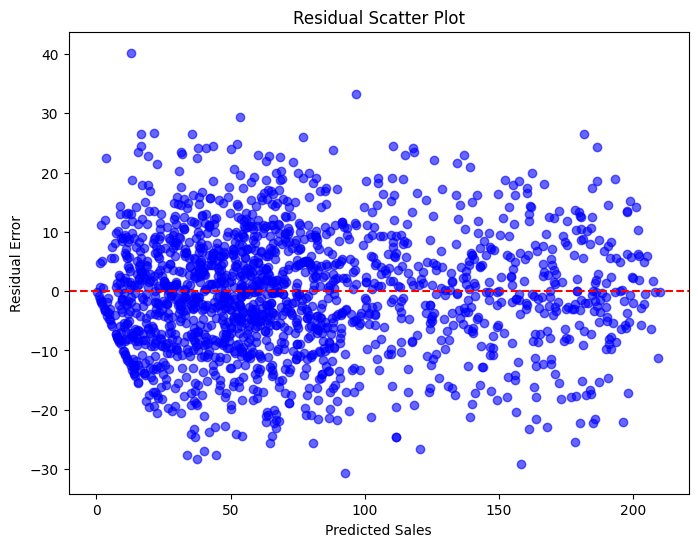

In [25]:
# ==============================================================================
# RESIDUAL SCATTER PLOT
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6,
    color="blue"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")

plt.ylabel("Residual Error")

plt.title("Residual Scatter Plot")

plt.show()

In [26]:
# ==============================================================================
# CROSS VALIDATION
# ==============================================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    cat_model,

    X,

    y,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

print("Cross Validation Scores")

print(cv_scores)

Cross Validation Scores
[0.96601866 0.96461573 0.96533091 0.9656168  0.96554241]


In [27]:
# ==============================================================================
# AVERAGE CROSS VALIDATION SCORE
# ==============================================================================

print("Average CV Score :", round(cv_scores.mean(),4))

Average CV Score : 0.9654


In [28]:
# ==============================================================================
# PERFORMANCE SUMMARY
# ==============================================================================

summary = pd.DataFrame({

    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Adjusted R²",
        "MAPE",
        "Cross Validation"
    ],

    "Value":[
        mae,
        mse,
        rmse,
        test_r2,
        adjusted_r2,
        mape,
        cv_scores.mean()
    ]

})

summary

,Metric,Value
0,MAE,8.088697
1,MSE,103.846355
2,RMSE,10.190503
3,R²,0.963514
4,Adjusted R²,0.962866
5,MAPE,inf
6,Cross Validation,0.965425


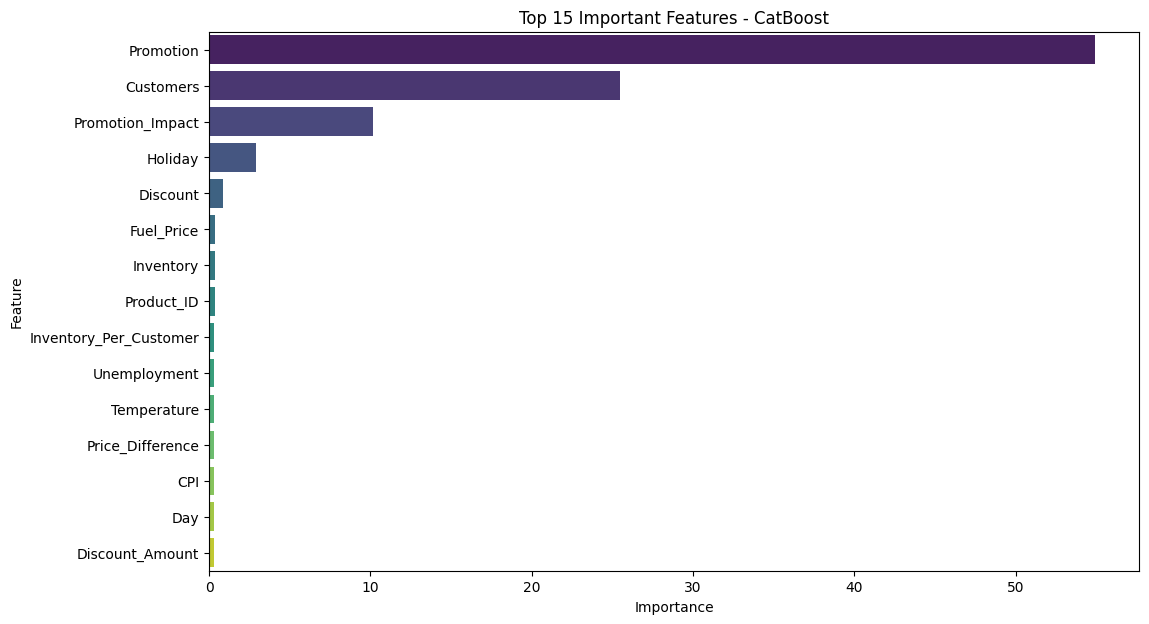

In [29]:
# ==============================================================================
# TOP 15 IMPORTANT FEATURES
# ==============================================================================

plt.figure(figsize=(12,7))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Important Features - CatBoost")

plt.show()

In [30]:
# ==============================================================================
# FEATURE IMPORTANCE TABLE
# ==============================================================================

importance.head(20)

,Feature,Importance
5,Promotion,54.912694
15,Customers,25.480356
29,Promotion_Impact,10.181680
4,Holiday,2.940077
14,Discount,0.887477
8,Fuel_Price,0.381557
11,Inventory,0.355149
1,Product_ID,0.340571
25,Inventory_Per_Customer,0.322620
10,Unemployment,0.314515


In [31]:
# ==============================================================================
# SAVE CATBOOST MODEL
# ==============================================================================

import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    cat_model,
    "model/catboost_model.pkl"
)

print("CatBoost Model Saved Successfully")


CatBoost Model Saved Successfully


In [32]:
# ==============================================================================
# SAVE PREDICTIONS
# ==============================================================================

os.makedirs("dataset", exist_ok=True)

prediction_df.to_csv(
    "dataset/catboost_predictions.csv",
    index=False
)

print("Prediction File Saved Successfully")

Prediction File Saved Successfully


In [33]:
# ==============================================================================
# SAVE PERFORMANCE REPORT
# ==============================================================================

summary.to_csv(
    "dataset/CatBoost_Performance.csv",
    index=False
)

print("Performance Report Saved Successfully")

Performance Report Saved Successfully


In [34]:
# ==============================================================================
# VERIFY MODEL FILES
# ==============================================================================

print(os.listdir("model"))

['catboost_model.pkl', 'decision_tree.pkl', 'label_encoder.pkl', 'lightgbm_model.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl', 'xgboost_model.pkl']


In [35]:
# ==============================================================================
# VERIFY DATASET FILES
# ==============================================================================

print(os.listdir("dataset"))

['CatBoost_Performance.csv', 'catboost_predictions.csv', 'DecisionTree_Performance.csv', 'decision_tree_predictions.csv', 'LightGBM_Performance.csv', 'lightgbm_predictions.csv', 'Linear_Regression_Performance.csv', 'linear_regression_predictions.csv', 'RandomForest_Performance.csv', 'random_forest_predictions.csv', 'XGBoost_Performance.csv', 'xgboost_predictions.csv']


In [36]:
# ==============================================================================
# BUSINESS INTERPRETATION
# ==============================================================================

print("Business Interpretation")

print("- CatBoost effectively handles complex relationships in retail demand data.")
print("- It reduces overfitting through gradient boosting.")
print("- Feature importance identifies the most influential variables.")
print("- Suitable for accurate retail demand forecasting.")
print("- Compare results with Random Forest, XGBoost and LightGBM.")

Business Interpretation
- CatBoost effectively handles complex relationships in retail demand data.
- It reduces overfitting through gradient boosting.
- Feature importance identifies the most influential variables.
- Suitable for accurate retail demand forecasting.
- Compare results with Random Forest, XGBoost and LightGBM.


In [37]:
# ==============================================================================
# MODEL SUMMARY
# ==============================================================================

print("="*60)

print("CATBOOST MODEL SUMMARY")

print("="*60)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("Features Used    :", X.shape[1])

print("="*60)

CATBOOST MODEL SUMMARY
Training Samples : 6880
Testing Samples  : 1721
Features Used    : 30
